<a href="https://colab.research.google.com/github/the1975/Data-Processing/blob/main/Project_Data_Processing/Analisis_Sentimen_World_Cup_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Analisis Sentimen Publik Terhadap Piala Dunia FIFA 2026 Media Sosial (Youtube), Menggunakan Machine Learning***

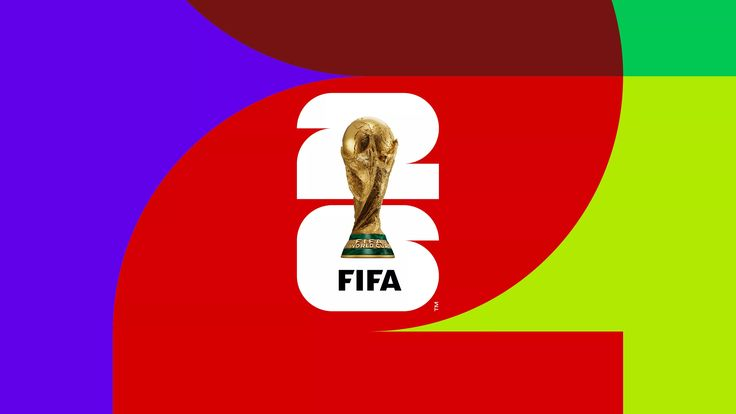

**Data diambil kamis, 14 Mei 2026**

In [ ]:
# Install library
!pip install google-api-python-client

# Import
from googleapiclient.discovery import build
import pandas as pd

# Masukkan API key lo
API_KEY =

# Connect ke YouTube
youtube = build('youtube', 'v3', developerKey=API_KEY)

# Search video FIFA 2026
request = youtube.search().list(
    q="FIFA World Cup 2026",
    part="snippet",
    type="video",
    maxResults=50  # naikin dari 10 ke 50
)
response = request.execute()

# Cek hasilnya
for item in response['items']:
    print(item['snippet']['title'])

FIFA World Cup 2026™ Final Halftime Show
One month to go | The World Arrives | FIFA World Cup 2026™
Madonna, Shakira &amp; BTS to co-headline FIFA World Cup 2026™ Final Halftime Show
World Cup 2026: FIFA under fire for ticket prices • FRANCE 24 English
Do You Believe? Everything Can Happen on Home Soil | FIFA World Cup 2026™
Seattle gears up for 2026 FIFA World Cup as leaders boost transit, encourage ridership
The 2026 World Cup is a Mess. Here is How it Actually Works
FIFA World Cup 2026™ Match Schedule Reveal
TRIONDA ​the Official Match Ball of the 2026 FIFA World Cup #adidas #fifa #worldcup2026
The FIFA World Cup 2026™ official match ball is here!
BRAZIL vs FRANCE - Final FIFA World Cup 2026 | Full Match All Goals | Simulation PES
My World Cup 2026 Prediction
THE 2026 WORLD CUP STADIUMS ARE ANNOUNCED ✅🏟️
I Spent HOW MUCH to COMPLETE the Panini World Cup 2026 Sticker Album?!
Alexi Lalas’ 48 team 2026 FIFA World Cup™ power rankings 📈
Is the NEW 2026 World Cup Ball Any Good?
2026 World

In [ ]:
# Ambil video ID dulu
video_ids = [item['id']['videoId'] for item in response['items']]

# Ambil komentar dari tiap video
comments = []

for video_id in video_ids:
    try:
        comment_request = youtube.commentThreads().list(
            part="snippet",
            videoId=video_id,
            maxResults=50
        )
        comment_response = comment_request.execute()

        for item in comment_response['items']:
            comment = item['snippet']['topLevelComment']['snippet']['textDisplay']
            comments.append({'video_id': video_id, 'comment': comment})
    except:
        pass  # skip video yang komentarnya dimatiin

# Jadiin DataFrame
df_comments = pd.DataFrame(comments)
print(df_comments.shape)
print(df_comments.head())

(2018, 2)
      video_id                                            comment
0  lqe-RS6HeMU  That half time show with those 3 Global Citize...
1  lqe-RS6HeMU  That last line genuinely gave me chills. &#39;...
2  lqe-RS6HeMU      Que se presente BTS en la apertura ya porfaaa
3  lqe-RS6HeMU  Que se presente BTS con la canción Body to Bod...
4  lqe-RS6HeMU  Mejor presenten la canción de BTS, Body to Bod...


In [ ]:
import re

def clean_text(text):
    text = re.sub(r'&#\d+;', '', text)  # hapus karakter html kayak &#39;
    text = re.sub(r'http\S+', '', text)  # hapus link
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # hapus angka & simbol
    text = text.lower().strip()  # lowercase
    return text

df_comments['clean_comment'] = df_comments['comment'].apply(clean_text)

# Hapus yang kosong setelah dibersihkan
df_comments = df_comments[df_comments['clean_comment'] != '']

print(df_comments.shape)
print(df_comments[['comment', 'clean_comment']].head())

(1885, 3)
                                             comment  \
0  That half time show with those 3 Global Citize...   
1  That last line genuinely gave me chills. &#39;...   
2      Que se presente BTS en la apertura ya porfaaa   
3  Que se presente BTS con la canción Body to Bod...   
4  Mejor presenten la canción de BTS, Body to Bod...   

                                       clean_comment  
0  that half time show with those  global citizen...  
1  that last line genuinely gave me chills who st...  
2      que se presente bts en la apertura ya porfaaa  
3  que se presente bts con la cancin body to body...  
4  mejor presenten la cancin de bts body to body ...  


In [ ]:
!pip install textblob

from textblob import TextBlob

def get_sentiment(text):
    score = TextBlob(text).sentiment.polarity
    if score > 0.1:
        return 'Positif'
    elif score < -0.1:
        return 'Negatif'
    else:
        return 'Netral'

df_comments['sentiment'] = df_comments['clean_comment'].apply(get_sentiment)

print(df_comments['sentiment'].value_counts())

sentiment
Netral     1158
Positif     556
Negatif     171
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

# Pisah fitur & label
X = df_comments['clean_comment']
y = df_comments['sentiment']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TF-IDF
tfidf = TfidfVectorizer(max_features=500)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Training model
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

# Evaluasi
y_pred = model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     Negatif       1.00      0.04      0.07        26
      Netral       0.76      0.96      0.85       242
     Positif       0.82      0.51      0.63       109

    accuracy                           0.77       377
   macro avg       0.86      0.51      0.52       377
weighted avg       0.79      0.77      0.73       377



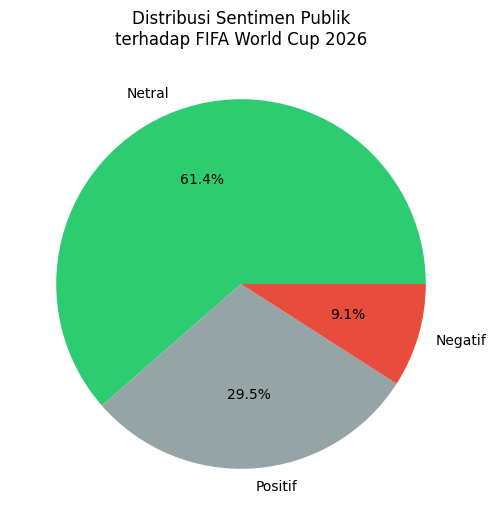

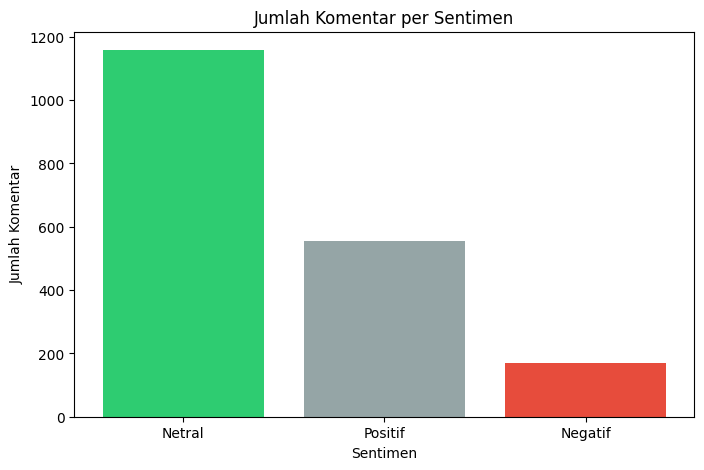

In [ ]:
import matplotlib.pyplot as plt

# Hitung distribusi sentimen
sentiment_counts = df_comments['sentiment'].value_counts()

# Pie chart
plt.figure(figsize=(8,6))
plt.pie(sentiment_counts,
        labels=sentiment_counts.index,
        autopct='%1.1f%%',
        colors=['#2ecc71', '#95a5a6', '#e74c3c'])
plt.title('Distribusi Sentimen Publik\nterhadap FIFA World Cup 2026')
plt.show()

# Bar chart
plt.figure(figsize=(8,5))
plt.bar(sentiment_counts.index, sentiment_counts.values,
        color=['#2ecc71', '#95a5a6', '#e74c3c'])
plt.title('Jumlah Komentar per Sentimen')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Komentar')
plt.show()

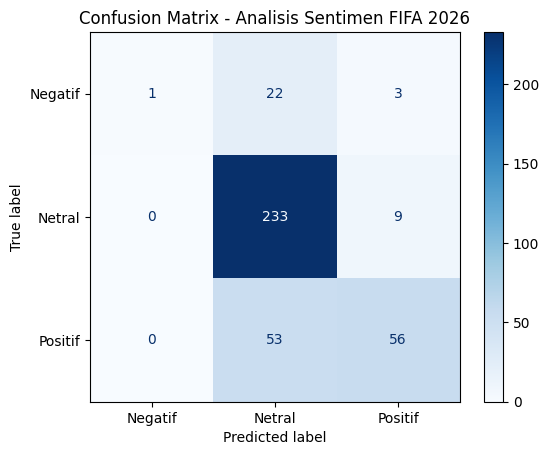

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Negatif', 'Netral', 'Positif'],
    cmap='Blues'
)
plt.title('Confusion Matrix - Analisis Sentimen FIFA 2026')
plt.show()

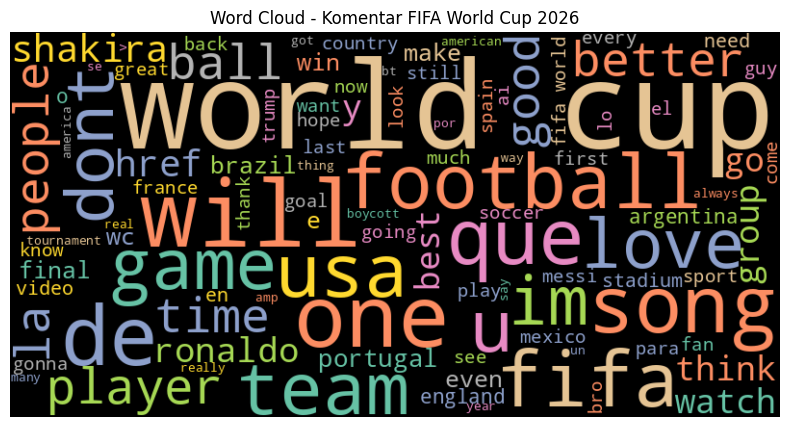

In [ ]:
!pip install wordcloud

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Gabungin semua komentar jadi satu string
all_text = ' '.join(df_comments['clean_comment'])

# Bikin word cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='black',
    colormap='Set2',
    max_words=100
).generate(all_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Komentar FIFA World Cup 2026')
plt.show()

In [ ]:
df_comments.to_csv('hasil_sentimen_fifa2026.csv', index=False)
print("Data berhasil disimpan!")

Data berhasil disimpan!


In [ ]:
import numpy as np

df = pd.read_csv('hasil_sentimen_fifa2026.csv')
df.head()

,video_id,comment,clean_comment,sentiment
0,lqe-RS6HeMU,That half time show with those 3 Global Citize...,that half time show with those global citizen...,Netral
1,lqe-RS6HeMU,That last line genuinely gave me chills. &#39;...,that last line genuinely gave me chills who st...,Positif
2,lqe-RS6HeMU,Que se presente BTS en la apertura ya porfaaa,que se presente bts en la apertura ya porfaaa,Netral
3,lqe-RS6HeMU,Que se presente BTS con la canción Body to Bod...,que se presente bts con la cancin body to body...,Netral
4,lqe-RS6HeMU,"Mejor presenten la canción de BTS, Body to Bod...",mejor presenten la cancin de bts body to body ...,Netral


In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
video_id,0
comment,0
clean_comment,0
sentiment,0
